In [2]:
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from torchvision import transforms
from torchvision.transforms import InterpolationMode

In [6]:
class Cutout:
    def __init__(self, num_holes=4, cut_ratio=0.2, fill=0):
        self.num_holes = num_holes
        self.cut_ratio = cut_ratio
        self.fill = fill

    def __call__(self, img):
        arr = np.asarray(img, dtype=np.uint8).copy()
        h, w = arr.shape[:2]
        if h == 0 or w == 0:
            return img

        cut_size = max(1, int(min(h, w) * self.cut_ratio))
        half = cut_size // 2

        for _ in range(max(0, self.num_holes)):
            cy = np.random.randint(0, h)
            cx = np.random.randint(0, w)

            y1 = max(0, cy - half)
            y2 = min(h, cy + half)
            x1 = max(0, cx - half)
            x2 = min(w, cx + half)
            arr[y1:y2, x1:x2] = self.fill

        return Image.fromarray(arr)


class MaskedBernoulliNoiseFast:
    def __init__(self, noise=0.05, min_=0, max_=1):
        self.noise = noise
        self.min_ = min_
        self.max_ = max_

    def __call__(self, img):
        arr = np.asarray(img, dtype=np.uint8)
        h, w = arr.shape[:2]
        if h == 0 or w == 0:
            return img

        wafer_mask = arr > 0
        bernoulli_mask = np.random.rand(h, w) < self.noise
        mask = wafer_mask & bernoulli_mask

        out = arr.copy()
        noise_value = 1 + np.random.randint(self.min_, self.max_ + 1, size=(h, w))
        out[mask] = noise_value[mask].astype(np.uint8)
        return Image.fromarray(out)

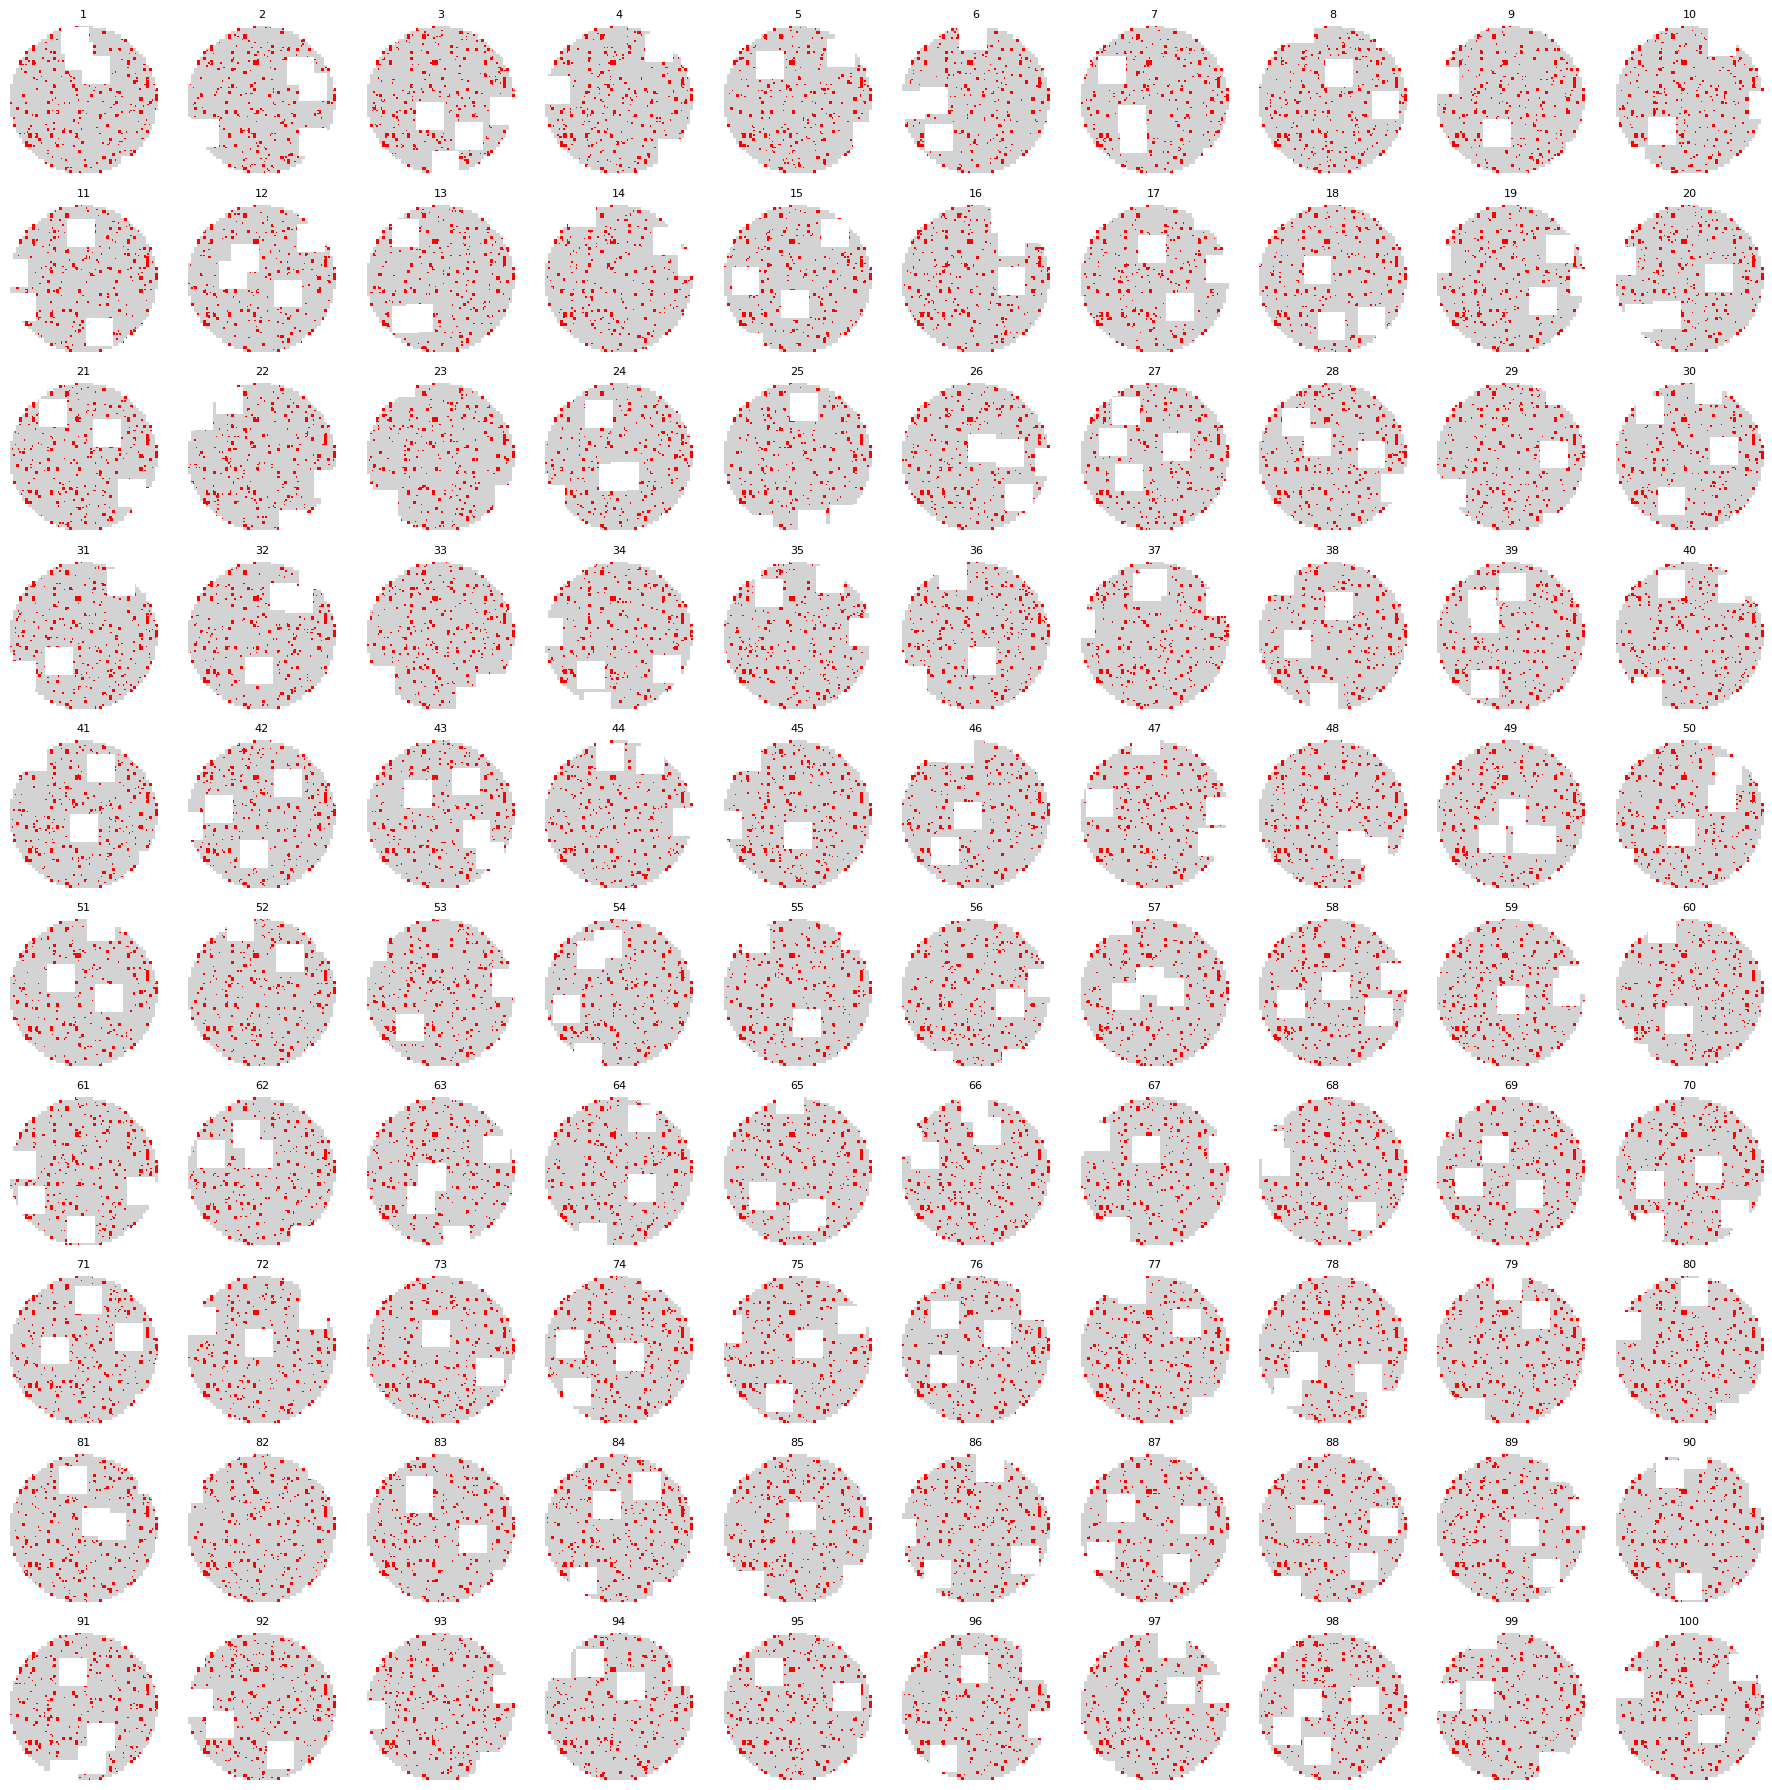

In [7]:
# -----------------------------
# 2. 시각화 함수
# -----------------------------
def show_wbm(ax, arr, title=None):
    cmap = ListedColormap(["white", "lightgray", "red"])
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)
    ax.imshow(arr, cmap=cmap, norm=norm, interpolation="nearest")
    if title is not None:
        ax.set_title(title, fontsize=8)
    ax.axis("off")


# -----------------------------
# 3. 데이터 불러오기
# -----------------------------
labeled_path = "./data/wm811k/preprocessing/labeled.pkl"
unlabeled_path = "./data/wm811k/preprocessing/unlabeled.pkl"

use_labeled = True
sample_index = 0
image_size = 96

if use_labeled:
    df = pd.read_pickle(labeled_path)
else:
    df = pd.read_pickle(unlabeled_path)

wafer = df.iloc[sample_index]["waferMap"]
img = Image.fromarray(wafer.astype(np.uint8))

# resize 먼저
resize_tf = transforms.Resize((image_size, image_size), interpolation=InterpolationMode.NEAREST)
img_resized = resize_tf(img)

# strong augmentation = cutout + noise
cutout_tf = Cutout(num_holes=4, cut_ratio=0.2, fill=0)
noise_tf = MaskedBernoulliNoiseFast(noise=0.05, min_=0, max_=1)

# -----------------------------
# 4. 100장 생성
# -----------------------------
augmented_images = []
for _ in range(100):
    aug_img = noise_tf(cutout_tf(img_resized))
    augmented_images.append(np.asarray(aug_img, dtype=np.uint8))

# -----------------------------
# 5. 10x10 grid 출력
# -----------------------------
fig, axes = plt.subplots(10, 10, figsize=(18, 18))

for i, ax in enumerate(axes.flat):
    show_wbm(ax, augmented_images[i], title=str(i + 1))

plt.tight_layout()
plt.show()